In [1]:
import pandas as pd
from ydata_profiling import ProfileReport

In [2]:
# Load dataset
df = pd.read_csv("output.csv")


In [ ]:

X = df.drop(columns=["fraud_history_approval_rejection_status_encoded"])  # Adjust as needed
X = X.select_dtypes(include=['number'])

In [4]:
Y = df["fraud_history_approval_rejection_status_encoded"]  # Adjust as needed

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

train_size=.80
val_size=.15
test_size=.5
random_state=42
# Ensure the total number of rows matches the required split sizes
total_size = train_size + val_size + test_size
if len(X) < total_size:
    raise ValueError(f"The dataset must have at least {total_size} rows to split into "
                     f"{train_size} training, {val_size} validation, and {test_size} test samples.")


# Split the data into training and remaining
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, train_size=train_size, random_state=random_state, stratify=Y)

# Split the remaining data into validation and test
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, train_size=val_size, random_state=random_state, stratify=Y_temp)


In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [7]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

C:\Users\Vandana\anaconda3\envs\my_env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


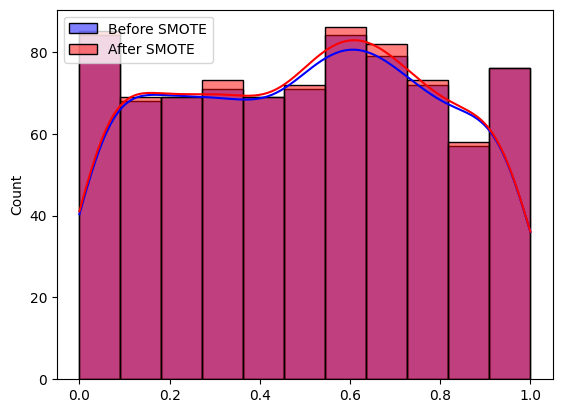

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(X_train[:, 0], label="Before SMOTE", color="blue", kde=True)
sns.histplot(X_train_resampled[:, 0], label="After SMOTE", color="red", kde=True)
plt.legend()
plt.show()


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation
from tensorflow.keras.metrics import Precision, Recall



In [10]:
model = Sequential()

# Input layer
model.add(Dense(39, activation='relu', input_dim=39))  # Match input features
model.add(BatchNormalization())  # Helps stabilize training

# Hidden layers with dropout to prevent overfitting
for _ in range(7):  
    model.add(Dense(64))  
    model.add(BatchNormalization())  # Place before activation  
    model.add(Activation('relu'))  
    model.add(Dropout(0.3))  # Enable dropout  


# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model with optimized settings
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Reduce learning rate for better stability
    loss='binary_crossentropy',
    metrics=['accuracy',Precision(), Recall()]
)

history = model.fit(
    X_train_resampled, Y_train_resampled,
    validation_data=(X_val, Y_val),
    epochs=20, batch_size=20,
    verbose=2
)


C:\Users\Vandana\anaconda3\envs\my_env\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
41/41 - 15s - 374ms/step - accuracy: 0.5037 - loss: 0.8355 - precision: 0.5058 - recall: 0.3202 - val_accuracy: 0.7000 - val_loss: 0.6908 - val_precision: 0.6875 - val_recall: 0.7333
Epoch 2/20
41/41 - 1s - 32ms/step - accuracy: 0.5074 - loss: 0.7897 - precision: 0.5085 - recall: 0.4409 - val_accuracy: 0.6667 - val_loss: 0.6856 - val_precision: 0.6190 - val_recall: 0.8667
Epoch 3/20
41/41 - 1s - 22ms/step - accuracy: 0.5493 - loss: 0.7486 - precision: 0.5521 - recall: 0.5222 - val_accuracy: 0.6000 - val_loss: 0.6841 - val_precision: 0.5600 - val_recall: 0.9333
Epoch 4/20
41/41 - 1s - 20ms/step - accuracy: 0.5234 - loss: 0.7534 - precision: 0.5237 - recall: 0.5172 - val_accuracy: 0.7667 - val_loss: 0.6791 - val_precision: 0.7000 - val_recall: 0.9333
Epoch 5/20
41/41 - 1s - 33ms/step - accuracy: 0.5259 - loss: 0.7558 - precision: 0.5262 - recall: 0.5197 - val_accuracy: 0.6667 - val_loss: 0.6701 - val_precision: 0.6087 - val_recall: 0.9333
Epoch 6/20
41/41 - 1s - 29ms/step - ac

In [11]:
import numpy as np
Y_test_pred_prob = model.predict(X_test)
Y_test_pred = (Y_test_pred_prob > 0.5).astype(int)

# Convert probabilities to binary classifications
Y_test_pred_binary = np.where(Y_test_pred >= 0.5, 1, 0)

# Evaluate the model
test_accuracy = accuracy_score(Y_test, Y_test_pred_binary)
test_precision = precision_score(Y_test, Y_test_pred_binary)
test_recall = recall_score(Y_test, Y_test_pred_binary)
test_f1 = f1_score(Y_test, Y_test_pred_binary)

print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.2f}")
print(f"Precision: {test_precision:.2f}")
print(f"Recall: {test_recall:.2f}")
print(f"F1-Score: {test_f1:.2f}")
print("\nClassification Report (Test):")
print(classification_report(Y_test, Y_test_pred_binary))

# Confusion Matrix
print("\nConfusion Matrix (Test):")
print(confusion_matrix(Y_test, Y_test_pred_binary))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step

Test Set Evaluation:
Accuracy: 0.91
Precision: 0.85
Recall: 0.99
F1-Score: 0.92

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.84      0.91        87
           1       0.85      0.99      0.92        83

    accuracy                           0.91       170
   macro avg       0.92      0.91      0.91       170
weighted avg       0.92      0.91      0.91       170


Confusion Matrix (Test):
[[73 14]
 [ 1 82]]
